In [1]:
import pandas as pd

df = pd.read_csv('thai_accidental_dataset.csv')

# clean เหมือนที่ทำไปแล้ว
fill_columns = ['province', 'first_vehicle', 'road_characteristic', 'weather']
for col in fill_columns:
    df[col] = df[col].fillna('ไม่ระบุ')

df['time'] = pd.to_datetime(df['time'])
df['hour'] = df['time'].dt.hour

# สร้าง target: ตาย (1) หรือ ไม่ตาย (0)
df['target'] = (df['fatalities'] > 0).astype(int)

# เช็คว่าข้อมูล target สมดุลแค่ไหน
print(df['target'].value_counts(normalize=True))

target
0    0.883409
1    0.116591
Name: proportion, dtype: float64


In [2]:
# เลือก features ที่จะใช้ทำนาย (ต้องเป็นสิ่งที่รู้ "ก่อน" เกิดเหตุ)
features = ['province', 'first_vehicle', 'road_characteristic', 
            'cause_clean', 'weather', 'hour']

# ต้องมี cause_clean ก่อน (ถ้ายังไม่ได้ทำในไฟล์นี้ ต้องรัน cleaning เดิมก่อน)
cause_mapping = {
    'เบรคกระทันหัน': 'เบรกกะทันหัน', 'เบรคกะทันหัน': 'เบรกกะทันหัน',
    'เบครกระทันหัน': 'เบรกกะทันหัน',
    # (ใส่ mapping เดิมทั้งหมดที่เคยทำ)
}
df['cause_clean'] = df['cause'].replace(cause_mapping)

X = df[features]
y = df['target']

# One-Hot Encoding: แปลง text เป็นตัวเลข
X_encoded = pd.get_dummies(X, columns=['province', 'first_vehicle', 
                                          'road_characteristic', 
                                          'cause_clean', 'weather'])

print(X_encoded.shape)
print(X_encoded.columns[:10])  # ดู 10 คอลัมน์แรกที่เกิดขึ้นใหม่

(151778, 297)
Index(['hour', 'province_กระบี่', 'province_กรุงเทพมหานคร',
       'province_กาญจนบุรี', 'province_กาฬสินธุ์', 'province_กำแพงเพชร',
       'province_ขอนแก่น', 'province_จันทบุรี', 'province_ฉะเชิงเทรา',
       'province_ชลบุรี'],
      dtype='str')


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

Train size: (121422, 297)
Test size: (30356, 297)


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [4]:
y_pred = model.predict(X_test)

In [5]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[26649   168]
 [ 3351   188]]
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     26817
           1       0.53      0.05      0.10      3539

    accuracy                           0.88     30356
   macro avg       0.71      0.52      0.52     30356
weighted avg       0.85      0.88      0.84     30356



In [6]:
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

print(confusion_matrix(y_test, y_pred_balanced))
print(classification_report(y_test, y_pred_balanced))

[[20139  6678]
 [ 1319  2220]]
              precision    recall  f1-score   support

           0       0.94      0.75      0.83     26817
           1       0.25      0.63      0.36      3539

    accuracy                           0.74     30356
   macro avg       0.59      0.69      0.60     30356
weighted avg       0.86      0.74      0.78     30356



In [7]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[21941  4876]
 [ 2009  1530]]
              precision    recall  f1-score   support

           0       0.92      0.82      0.86     26817
           1       0.24      0.43      0.31      3539

    accuracy                           0.77     30356
   macro avg       0.58      0.63      0.59     30356
weighted avg       0.84      0.77      0.80     30356



In [8]:

# ดูค่าความน่าจะเป็นแทนคำทายตรงๆ (0 หรือ 1)
y_proba = model_balanced.predict_proba(X_test)[:, 1]

# ลองปรับ threshold ให้ต่ำลง (เข้มงวดน้อยลง เตือนง่ายขึ้น)
threshold = 0.3
y_pred_custom = (y_proba >= threshold).astype(int)

print(confusion_matrix(y_test, y_pred_custom))
print(classification_report(y_test, y_pred_custom))

[[ 8302 18515]
 [  270  3269]]
              precision    recall  f1-score   support

           0       0.97      0.31      0.47     26817
           1       0.15      0.92      0.26      3539

    accuracy                           0.38     30356
   macro avg       0.56      0.62      0.36     30356
weighted avg       0.87      0.38      0.44     30356



In [9]:
for t in [0.35, 0.4, 0.45]:
    y_pred_t = (y_proba >= t).astype(int)
    print(f"--- Threshold {t} ---")
    print(classification_report(y_test, y_pred_t, output_dict=False))

--- Threshold 0.35 ---
              precision    recall  f1-score   support

           0       0.96      0.41      0.58     26817
           1       0.16      0.88      0.28      3539

    accuracy                           0.47     30356
   macro avg       0.56      0.64      0.43     30356
weighted avg       0.87      0.47      0.54     30356

--- Threshold 0.4 ---
              precision    recall  f1-score   support

           0       0.95      0.55      0.70     26817
           1       0.19      0.79      0.30      3539

    accuracy                           0.58     30356
   macro avg       0.57      0.67      0.50     30356
weighted avg       0.86      0.58      0.65     30356

--- Threshold 0.45 ---
              precision    recall  f1-score   support

           0       0.95      0.64      0.77     26817
           1       0.21      0.73      0.33      3539

    accuracy                           0.65     30356
   macro avg       0.58      0.68      0.55     30356
weight

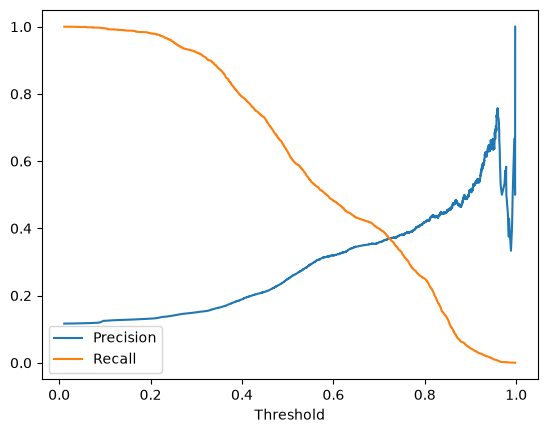

In [10]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.savefig('threshold_tradeoff.png')

In [11]:
import pandas as pd

coefficients = pd.DataFrame({
    'feature': X_encoded.columns,
    'coefficient': model_balanced.coef_[0]
}).sort_values('coefficient', ascending=False)

print("ปัจจัยที่เพิ่มความเสี่ยงตายมากที่สุด:")
print(coefficients.head(15))

print("\nปัจจัยที่ลดความเสี่ยงตายมากที่สุด:")
print(coefficients.tail(15))

ปัจจัยที่เพิ่มความเสี่ยงตายมากที่สุด:
                                               feature  coefficient
202       cause_clean_ความประมาท/เร่งรีบ (วิ่งตัดหน้า)     2.953646
252  cause_clean_อาการป่วย หรือการไร้ความสามารถทางป...     2.944771
185             cause_clean_การกระทำที่สุ่มเสี่ยงบนถนน     2.744510
79                            first_vehicle_คนเดินเท้า     1.976798
145    road_characteristic_ทางแยกรูปตัว T+บนช่วงลาดชัน     1.926071
138                 road_characteristic_ทางแยกรูปตัว +     1.421096
186                  cause_clean_การซ่อม/สร้างบนสายทาง     1.335174
119          road_characteristic_ทางรถไฟตัดผ่าน+ที่ราบ     1.331477
209                             cause_clean_ทำงานบนถนน     1.305286
234  cause_clean_รถเสียไม่แสดงเครื่องหมายหรือสัญญาณ...     1.297570
190               cause_clean_ขับรถคร่อมเส้นแบ่งทิศทาง     1.199336
194                            cause_clean_ขับรถย้อนศร     1.172276
101           road_characteristic_ทางคนเดินเท้า+ที่ราบ     1.067047
80        

In [12]:
print(df[df['cause_clean'] == 'บรรทุกเกินอัตรา'].shape[0])
print(df[df['cause_clean'] == 'บรรทุกเกินอัตรา']['fatalities'].mean())

365
0.024657534246575342


In [13]:
suspicious_causes = ['บรรทุกเกินอัตรา', 'ยางรถยนต์ชำรุด', 'ยางเสื่อมสภาพ/ยางแตก', 
                      'เครื่องยนต์ขัดข้อง', 'หยุดรถกะทันหัน']

for cause in suspicious_causes:
    count = df[df['cause_clean'] == cause].shape[0]
    rate = df[df['cause_clean'] == cause]['fatalities'].mean()
    print(f"{cause}: n={count}, fatality_rate={rate:.3f}")

บรรทุกเกินอัตรา: n=365, fatality_rate=0.025
ยางรถยนต์ชำรุด: n=552, fatality_rate=0.043
ยางเสื่อมสภาพ/ยางแตก: n=1629, fatality_rate=0.023
เครื่องยนต์ขัดข้อง: n=99, fatality_rate=0.040
หยุดรถกะทันหัน: n=84, fatality_rate=0.083


In [14]:
rare = df['cause_clean'].value_counts()
rare_causes = rare[rare < 50].index
df['cause_clean'] = df['cause_clean'].replace(rare_causes, 'อื่นๆ (สาเหตุพบน้อย)')
print(df['cause_clean'].nunique())

48


In [15]:
from xgboost import XGBClassifier

# คำนวณสัดส่วนถ่วงน้ำหนักเอง (แม่นกว่า class_weight='balanced' แบบเดา)
scale = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", scale)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_proba_xgb >= 0.4).astype(int)  # ใช้ threshold 0.4 ที่เลือกไว้

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

scale_pos_weight: 7.576817122271668
[[15027 11790]
 [  713  2826]]
              precision    recall  f1-score   support

           0       0.95      0.56      0.71     26817
           1       0.19      0.80      0.31      3539

    accuracy                           0.59     30356
   macro avg       0.57      0.68      0.51     30356
weighted avg       0.87      0.59      0.66     30356



In [16]:
print(df['agency'].nunique())
print(df['route'].nunique())

3
4594


In [17]:
df['is_night'] = ((df['hour'] >= 22) | (df['hour'] <= 4)).astype(int)
df['day_of_week'] = df['time'].dt.day_name()
df['target'] = (df['fatalities'] > 0).astype(int)

features = ['province', 'first_vehicle', 'road_characteristic', 
            'cause_clean', 'weather', 'hour', 'agency',
            'injuries', 'is_night', 'day_of_week']

X = df[features]
y = df['target']

categorical_cols = ['province', 'first_vehicle', 'road_characteristic', 
                     'cause_clean', 'weather', 'agency', 'day_of_week']

X_encoded = pd.get_dummies(X, columns=categorical_cols)

print(X_encoded.shape)

(151778, 253)


In [18]:
print(X[categorical_cols].isnull().sum().sum())  # ควรเป็น 0
print(df['injuries'].isnull().sum())  # ควรเป็น 0 เช่นกัน

0
0


In [19]:
from sklearn.model_selection import train_test_split

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

scale2 = (y_train2 == 0).sum() / (y_train2 == 1).sum()

xgb_model2 = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale2,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model2.fit(X_train2, y_train2)

y_proba2 = xgb_model2.predict_proba(X_test2)[:, 1]
y_pred2 = (y_proba2 >= 0.4).astype(int)

print(confusion_matrix(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2))

[[17867  8950]
 [  801  2738]]
              precision    recall  f1-score   support

           0       0.96      0.67      0.79     26817
           1       0.23      0.77      0.36      3539

    accuracy                           0.68     30356
   macro avg       0.60      0.72      0.57     30356
weighted avg       0.87      0.68      0.74     30356



In [20]:
importance2 = pd.DataFrame({
    'feature': X_encoded.columns,
    'importance': xgb_model2.feature_importances_
}).sort_values('importance', ascending=False)

print(importance2.head(10))

                                          feature  importance
83                    first_vehicle_รถจักรยานยนต์    0.142175
244                         agency_กรมทางหลวงชนบท    0.062781
4                          province_กรุงเทพมหานคร    0.043785
11                                province_ชลบุรี    0.027574
1                                        injuries    0.025736
81                       first_vehicle_คนเดินเท้า    0.025067
92                  first_vehicle_รถสามล้อเครื่อง    0.020497
195      cause_clean_คน/รถ/สัตว์ตัดหน้ากระชั้นชิด    0.019705
82                        first_vehicle_รถจักรยาน    0.018913
196  cause_clean_ความประมาท/เร่งรีบ (วิ่งตัดหน้า)    0.015562


In [21]:
features_final = ['province', 'first_vehicle', 'road_characteristic', 
                   'cause_clean', 'weather', 'hour', 'agency',
                   'is_night', 'day_of_week']  # ตัด injuries ออก

X_final = df[features_final]
y_final = df['target']

categorical_cols_final = ['province', 'first_vehicle', 'road_characteristic', 
                           'cause_clean', 'weather', 'agency', 'day_of_week']

X_encoded_final = pd.get_dummies(X_final, columns=categorical_cols_final)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_encoded_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

scale3 = (y_train3 == 0).sum() / (y_train3 == 1).sum()

xgb_model3 = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale3,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model3.fit(X_train3, y_train3)

y_proba3 = xgb_model3.predict_proba(X_test3)[:, 1]
y_pred3 = (y_proba3 >= 0.4).astype(int)

print(confusion_matrix(y_test3, y_pred3))
print(classification_report(y_test3, y_pred3))

[[16104 10713]
 [  786  2753]]
              precision    recall  f1-score   support

           0       0.95      0.60      0.74     26817
           1       0.20      0.78      0.32      3539

    accuracy                           0.62     30356
   macro avg       0.58      0.69      0.53     30356
weighted avg       0.87      0.62      0.69     30356



In [22]:
import holidays

th_holidays = holidays.Thailand(years=range(2019, 2026))

df['is_holiday'] = df['time'].dt.date.astype(str).apply(
    lambda x: x in [str(d) for d in th_holidays]
).astype(int)

print(df['is_holiday'].value_counts())

is_holiday
0    133356
1     18422
Name: count, dtype: int64


In [23]:
features_final2 = ['province', 'first_vehicle', 'road_characteristic', 
                    'cause_clean', 'weather', 'hour', 'agency',
                    'is_night', 'day_of_week', 'is_holiday']

X_f2 = df[features_final2]
y_f2 = df['target']

categorical_cols_f2 = ['province', 'first_vehicle', 'road_characteristic', 
                        'cause_clean', 'weather', 'agency', 'day_of_week']

X_encoded_f2 = pd.get_dummies(X_f2, columns=categorical_cols_f2)

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_encoded_f2, y_f2, test_size=0.2, random_state=42, stratify=y_f2
)

scale4 = (y_train4 == 0).sum() / (y_train4 == 1).sum()

xgb_model4 = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale4, random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_model4.fit(X_train4, y_train4)

y_proba4 = xgb_model4.predict_proba(X_test4)[:, 1]
y_pred4 = (y_proba4 >= 0.4).astype(int)

print(confusion_matrix(y_test4, y_pred4))
print(classification_report(y_test4, y_pred4))

[[16140 10677]
 [  790  2749]]
              precision    recall  f1-score   support

           0       0.95      0.60      0.74     26817
           1       0.20      0.78      0.32      3539

    accuracy                           0.62     30356
   macro avg       0.58      0.69      0.53     30356
weighted avg       0.87      0.62      0.69     30356



In [24]:
import joblib

joblib.dump(xgb_model4, 'accident_risk_model.pkl')

model_columns = X_encoded_f2.columns.tolist()
joblib.dump(model_columns, 'model_columns.pkl')

['model_columns.pkl']

In [25]:
print(xgb_model4)
print(X_encoded_f2.shape)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)
(151778, 253)


In [26]:
import pandas as pd

df = pd.read_csv('thai_accidental_dataset.csv')

fill_columns = ['province', 'first_vehicle', 'road_characteristic', 'weather']
for col in fill_columns:
    df[col] = df[col].fillna('ไม่ระบุ')

cause_mapping = {
    'เบรคกระทันหัน': 'เบรกกะทันหัน',
    'เบรคกะทันหัน': 'เบรกกะทันหัน',
    'เบครกระทันหัน': 'เบรกกะทันหัน',
    'ระบบไฟฟ้ขัดข้อง': 'ระบบไฟฟ้าขัดข้อง',
    'ระบบไฟฟ้าของยานพาหนะขัดข้อง': 'ระบบไฟฟ้าขัดข้อง',
    'ขับรถไม่เปิดไฟ / ไม่ใช้แสงสว่างตามกำหนด': 'ขับรถไม่เปิดไฟ/ไม่ใช้แสงสว่างตามกำหนด',
    'ฝ่าฝืนสัญญาณไฟ / เครื่องหมายจราจร': 'ฝ่าฝืนสัญญาณไฟ/เครื่องหมายจราจร',
    'ไม่ให้สัญญาณชะลอ / เลี้ยว': 'ไม่ให้สัญญาณชะลอ/เลี้ยว',
    'อาการป่วย หรือการไร้ความสามารถทางประสาทหรือร่างกาย': 'อาการป่วยหรือการไร้ความสามารถทางประสาทหรือร่างกาย',
    'ฝ่าฝืนป้ายหยุดขณะออกจากทางร่วมทางแยก': 'ฝ่าฝืนป้ายหยุดขณะออกจากทางร่วมแยก',
    'ไม่ให้สัญญาณเข้าจอด หรือออกจากที่จอด': 'ไม่ให้สัญญาณเข้าจอด/ออกจากที่จอด',
    'แสงสว่างไม่เพียงพอหรือทัศนวิสัยกลางคืนไม่ดี': 'แสงสว่างไม่เพียงพอ',
    'ระยะมองเห็นจำกัด': 'ระยะการมองเห็นไม่เพียงพอ',
    'ขับรถเร็วเกินอัตราที่กำหนด': 'ขับรถเร็วเกินอัตรากำหนด',
}
df['cause_clean'] = df['cause'].replace(cause_mapping)

rare = df['cause_clean'].value_counts()
rare_causes = rare[rare < 50].index
df['cause_clean'] = df['cause_clean'].replace(rare_causes, 'อื่นๆ (สาเหตุพบน้อย)')

print("จำนวนหมวดหมู่:", df['cause_clean'].nunique())

จำนวนหมวดหมู่: 43


In [27]:
print(sorted(df['cause_clean'].unique()))

['ขับรถกระชั้นชิด', 'ขับรถคร่อมเส้นแบ่งทิศทาง', 'ขับรถตามกระชั้นชิด', 'ขับรถผิดช่องทาง', 'ขับรถย้อนศร', 'ขับรถเร็วเกินอัตรากำหนด', 'ขับรถไม่ชำนาญ / ไม่เป็น', 'คน/รถ/สัตว์ตัดหน้ากระชั้นชิด', 'ความประมาท/เร่งรีบ (วิ่งตัดหน้า)', 'ความเมื่อยล้า', 'ถนนลื่น', 'ถนนลื่น (เนื่องจากสภาพอากาศ)', 'ทางโค้งอันตราย', 'บรรทุกเกินอัตรา', 'ฝ่าฝืนป้ายหยุดขณะออกจากทางร่วมแยก', 'ฝ่าฝืนสัญญาณไฟ/เครื่องหมายจราจร', 'มีกองวัสดุ/สิ่งกีดขวาง', 'มีการตัดหน้าระยะกระชั้นชิด', 'มีสิ่งกีดขวางบนทางหลวง (วัสดุหรือสัตว์)', 'ยางรถยนต์ชำรุด', 'ยางเสื่อมสภาพ/ยางแตก', 'รถเสียไม่แสดงเครื่องหมายหรือสัญญาณไฟที่กำหนด', 'ระบบห้ามล้อขัดข้อง/ระบบเบรกชำรุด', 'ระยะการมองเห็นไม่เพียงพอ', 'สูญเสียการควบคุม', 'หยุดรถกะทันหัน', 'หลับใน', 'อื่นๆ', 'อื่นๆ (สาเหตุพบน้อย)', 'อุปกรณ์ยานพาหนะบกพร่อง', 'เครื่องยนต์ขัดข้อง', 'เบรคชำรุด', 'เปลี่ยนช่องทางกะทันหัน', 'เมาสุรา', 'แซงรถอย่างผิดกฎหมาย', 'แสงสว่างไม่เพียงพอ', 'โรคประจำตัว', 'ใช้โทรศัพท์เคลื่อนที่ขณะขับรถ', 'ไม่คุ้นเคยเส้นทาง/ขับรถไม่ชำนาญ', 'ไม่ยอมให้รถที่มีสิทธิ์ไปก่อน', 'ไม่ระบุ', 'ไ

In [28]:
df_check = pd.read_csv('thai_accidental_dataset.csv')
print("จำนวน cause ดิบ (ไม่ clean เลย):", df_check['cause'].nunique())

rare_check = df_check['cause'].value_counts()
rare_causes_check = rare_check[rare_check < 50].index
print("จำนวนหลังรวม rare<50 (ไม่ผ่าน mapping สะกดผิดก่อน):", 
      len(rare_check) - len(rare_causes_check) + 1)

จำนวน cause ดิบ (ไม่ clean เลย): 107
จำนวนหลังรวม rare<50 (ไม่ผ่าน mapping สะกดผิดก่อน): 48


In [29]:
print(df['cause_clean'].value_counts())

cause_clean
ขับรถเร็วเกินอัตรากำหนด                         108882
คน/รถ/สัตว์ตัดหน้ากระชั้นชิด                     10260
หลับใน                                           10168
อุปกรณ์ยานพาหนะบกพร่อง                            2727
เมาสุรา                                           2532
ไม่ระบุ                                           1657
มีการตัดหน้าระยะกระชั้นชิด                        1635
ยางเสื่อมสภาพ/ยางแตก                              1629
ฝ่าฝืนสัญญาณไฟ/เครื่องหมายจราจร                   1593
ถนนลื่น                                           1164
ไม่คุ้นเคยเส้นทาง/ขับรถไม่ชำนาญ                   1158
แซงรถอย่างผิดกฎหมาย                                705
มีกองวัสดุ/สิ่งกีดขวาง                             566
อื่นๆ (สาเหตุพบน้อย)                               564
ยางรถยนต์ชำรุด                                     552
ขับรถย้อนศร                                        522
ไม่ให้สัญญาณชะลอ/เลี้ยว                            507
สูญเสียการควบคุม                                   44

In [30]:

print(df['cause_clean'].value_counts().sum())
print(len(df))

151778
151778


In [31]:
from data_prep import load_and_clean_data

df = load_and_clean_data()
print("จำนวนหมวดหมู่:", df['cause_clean'].nunique())  # ต้องได้ 43
print("ผลรวม:", df['cause_clean'].value_counts().sum())  # ต้องได้ 151778

จำนวนหมวดหมู่: 43
ผลรวม: 151778


In [32]:
import os
print(os.getcwd())
print(os.path.exists('data_prep.py'))

/Users/achi/road-safety-project
True


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import joblib

from data_prep import FEATURES, CATEGORICAL_COLS

X_f2 = df[FEATURES]
y_f2 = df['target']

X_encoded_f2 = pd.get_dummies(X_f2, columns=CATEGORICAL_COLS)
print("จำนวนคอลัมน์:", X_encoded_f2.shape)

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_encoded_f2, y_f2, test_size=0.2, random_state=42, stratify=y_f2
)

scale4 = (y_train4 == 0).sum() / (y_train4 == 1).sum()

xgb_model4 = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    scale_pos_weight=scale4, random_state=42, n_jobs=-1, eval_metric='logloss'
)
xgb_model4.fit(X_train4, y_train4)

y_proba4 = xgb_model4.predict_proba(X_test4)[:, 1]
y_pred4 = (y_proba4 >= 0.4).astype(int)

print(confusion_matrix(y_test4, y_pred4))
print(classification_report(y_test4, y_pred4))

joblib.dump(xgb_model4, 'accident_risk_model.pkl')
joblib.dump(X_encoded_f2.columns.tolist(), 'model_columns.pkl')
print("บันทึกโมเดลเรียบร้อย")

จำนวนคอลัมน์: (151778, 248)
[[16163 10654]
 [  813  2726]]
              precision    recall  f1-score   support

           0       0.95      0.60      0.74     26817
           1       0.20      0.77      0.32      3539

    accuracy                           0.62     30356
   macro avg       0.58      0.69      0.53     30356
weighted avg       0.86      0.62      0.69     30356

บันทึกโมเดลเรียบร้อย


In [21]:
from data_prep import load_and_clean_data

df = load_and_clean_data()
print(df.shape)

(151778, 20)


In [22]:
EVAL_SET = [
    ("กดคันเร่งจนรถพุ่งเร็วเกินไป", "ขับรถเร็วเกินอัตรากำหนด"),
    ("ขับรถทั้งที่ตาปรือง่วงมาก", "หลับใน"),
    ("กินเหล้าเยอะแล้วยังขับรถกลับบ้าน", "เมาสุรา"),
    ("พิมพ์แชทตอบไลน์ระหว่างขับรถ", "ใช้โทรศัพท์เคลื่อนที่ขณะขับรถ"),
    ("รถกระบะบรรทุกของสูงจนล้นคันรถ", "บรรทุกเกินอัตรา"),
    ("ยางเก่ามากจนระเบิดกลางทาง", "ยางเสื่อมสภาพ/ยางแตก"),
    ("หน้าฝนถนนลื่นมาก", "ถนนลื่น (เนื่องจากสภาพอากาศ)"),
    ("ไม่มีไฟถนนเลยตอนกลางคืน", "แสงสว่างไม่เพียงพอ"),
    ("โค้งหักศอกมองไม่เห็นรถที่สวนมา", "ทางโค้งอันตราย"),
    ("วัวเดินตัดหน้ารถกะทันหันตอนกลางคืน", "คน/รถ/สัตว์ตัดหน้ากระชั้นชิด"),
    ("ขับสวนเลนผิดทาง", "ขับรถย้อนศร"),
    ("แซงตรงทางโค้งที่ห้ามแซง", "แซงรถอย่างผิดกฎหมาย"),
    ("เหยียบเบรกแล้วรถไม่หยุด", "ระบบห้ามล้อขัดข้อง/ระบบเบรกชำรุด"),
    ("นักท่องเที่ยวขับรถหลงทางแล้วเกิดอุบัติเหตุ", "ไม่คุ้นเคยเส้นทาง/ขับรถไม่ชำนาญ"),
    ("ขับจี้ท้ายรถคันหน้าตลอดทาง", "ขับรถตามกระชั้นชิด"),
    ("ปาดขวาแซงแล้วตัดเข้าเลนกะทันหัน", "เปลี่ยนช่องทางกะทันหัน"),
    ("มีเศษไม้ตกกลางถนนตอนกลางคืน", "มีสิ่งกีดขวางบนทางหลวง (วัสดุหรือสัตว์)"),
    ("ขับรถทางไกลจนเหนื่อยล้าเกินไป", "ความเมื่อยล้า"),
    ("ไม่หยุดให้รถทางเอกไปก่อนตรงทางแยก", "ไม่ยอมให้รถที่มีสิทธิ์ไปก่อน"),
    ("หัวใจวายเฉียบพลันขณะขับรถ", "โรคประจำตัว"),
    ("ขับผ่านสี่แยกทั้งที่ไฟยังแดงอยู่", "ฝ่าฝืนสัญญาณไฟ/เครื่องหมายจราจร"),
    ("รถดับกลางถนนเพราะเครื่องมีปัญหา", "เครื่องยนต์ขัดข้อง"),
    ("หักหลบแล้วรถหมุนควงสว่าน", "สูญเสียการควบคุม"),
    ("ขับอยู่เลนขวาสุดทั้งที่ต้องใช้เลนซ้าย", "ขับรถผิดช่องทาง"),
    ("มีกองทรายกองอยู่กลางถนน", "มีกองวัสดุ/สิ่งกีดขวาง"),
]

In [23]:
from sentence_transformers import SentenceTransformer, util

search_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

reference_terms = list(df['cause_clean'].unique()) + list(df['road_characteristic'].unique())
reference_embeddings = search_model.encode(reference_terms)

def search(query, top_k=5):
    query_embedding = search_model.encode(query)
    scores = util.cos_sim(query_embedding, reference_embeddings)[0]
    top_results = scores.argsort(descending=True)[:top_k]
    return [(reference_terms[i], round(float(scores[i]), 3)) for i in top_results]

print(search("ถนนมืดมองไม่เห็น"))
print(search("คนขับหลับคาพวงมาลัย"))
print(search("ฝนตกถนนลื่น"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[('ถนนลื่น', 0.579), ('ถนนลื่น (เนื่องจากสภาพอากาศ)', 0.529), ('ฝ่าฝืนสัญญาณไฟ/เครื่องหมายจราจร', 0.515), ('รถเสียไม่แสดงเครื่องหมายหรือสัญญาณไฟที่กำหนด', 0.501), ('ทางม้าลาย/คนเดินข้าม', 0.47)]
[('อุปกรณ์ยานพาหนะบกพร่อง', 0.595), ('ขับรถผิดช่องทาง', 0.575), ('เครื่องยนต์ขัดข้อง', 0.556), ('ระบบห้ามล้อขัดข้อง/ระบบเบรกชำรุด', 0.546), ('เบรคชำรุด', 0.537)]
[('ถนนลื่น (เนื่องจากสภาพอากาศ)', 0.783), ('ถนนลื่น', 0.698), ('มีการเปลี่ยนความกว้างช่องจราจร+ที่ราบ', 0.483), ('จุดกลับรถต่างระดับ+ที่ราบ', 0.432), ('มีการเปลี่ยนจำนวนช่องจราจร', 0.427)]


In [24]:
search_model_v2 = SentenceTransformer('intfloat/multilingual-e5-small')

reference_terms = list(df['cause_clean'].unique()) + list(df['road_characteristic'].unique())
reference_embeddings_v2 = search_model_v2.encode([f"passage: {t}" for t in reference_terms])

def search_v2(query, top_k=5):
    query_embedding = search_model_v2.encode(f"query: {query}")
    scores = util.cos_sim(query_embedding, reference_embeddings_v2)[0]
    top_results = scores.argsort(descending=True)[:top_k]
    return [(reference_terms[i], round(float(scores[i]), 3)) for i in top_results]

print(search_v2("ถนนมืดมองไม่เห็น"))
print(search_v2("คนขับหลับคาพวงมาลัย"))
print(search_v2("ฝนตกถนนลื่น"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[('แสงสว่างไม่เพียงพอ', 0.858), ('ไม่คุ้นเคยเส้นทาง/ขับรถไม่ชำนาญ', 0.853), ('ถนนลื่น', 0.847), ('ถนนลื่น (เนื่องจากสภาพอากาศ)', 0.847), ('ทางโค้งกว้าง+ไม่มีความลาดชัน', 0.845)]
[('ขับรถตามกระชั้นชิด', 0.849), ('ขับรถกระชั้นชิด', 0.849), ('หลับใน', 0.846), ('ใช้โทรศัพท์เคลื่อนที่ขณะขับรถ', 0.846), ('ขับรถไม่ชำนาญ / ไม่เป็น', 0.844)]
[('ถนนลื่น (เนื่องจากสภาพอากาศ)', 0.906), ('ถนนลื่น', 0.895), ('ทางโค้งหักศอก', 0.861), ('มีสิ่งกีดขวางบนทางหลวง (วัสดุหรือสัตว์)', 0.86), ('ทางลอด+ที่ราบ', 0.855)]


In [25]:
from sentence_transformers import SentenceTransformer, util
from thefuzz import fuzz
from data_prep import load_and_clean_data, SEARCH_SYNONYMS

df = load_and_clean_data()
search_model = SentenceTransformer('intfloat/multilingual-e5-small')  # ตัวเดิมที่โหลดเสร็จแล้ว ไม่ต้องโหลดใหม่

# สร้างวลี→หมวดหมู่ ครอบคลุมทุกหมวด (แม้ไม่มีใน SEARCH_SYNONYMS ก็ยังค้นหาได้ด้วยชื่อหมวดเอง)
phrase_to_category = {}
for category, synonyms in SEARCH_SYNONYMS.items():
    phrase_to_category[category] = category
    for phrase in synonyms:
        phrase_to_category[phrase] = category

for cat in df['cause_clean'].unique():
    if cat not in phrase_to_category:
        phrase_to_category[cat] = cat

all_phrases = list(phrase_to_category.keys())
phrase_embeddings = search_model.encode([f"passage: {p}" for p in all_phrases])


def hybrid_search(query, top_k=3, semantic_weight=0.85):
    query_embedding = search_model.encode(f"query: {query}")
    semantic_scores = util.cos_sim(query_embedding, phrase_embeddings)[0]

    category_best_score = {}
    for i, phrase in enumerate(all_phrases):
        category = phrase_to_category[phrase]
        sem_score = float(semantic_scores[i])
        lex_score = fuzz.partial_ratio(query, phrase) / 100
        combined = semantic_weight * sem_score + (1 - semantic_weight) * lex_score

        if category not in category_best_score or combined > category_best_score[category]:
            category_best_score[category] = combined

    ranked = sorted(category_best_score.items(), key=lambda x: -x[1])
    return ranked[:top_k]


print(hybrid_search("ถนนมืดมองไม่เห็น"))
print(hybrid_search("คนขับหลับคาพวงมาลัย"))
print(hybrid_search("ฝนตกถนนลื่น"))

print(hybrid_search("มัวแต่ก้มดูไลน์ตอนขับรถ"))
print(hybrid_search("รถบรรทุกของแน่นเกินจนอันตราย"))
print(hybrid_search("ยางแบนกลางทางตอนขับ"))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[('แสงสว่างไม่เพียงพอ', 0.9141651391983032), ('ทางโค้งอันตราย', 0.847402629852295), ('ระยะการมองเห็นไม่เพียงพอ', 0.8239239730834961)]
[('หลับใน', 0.9271888136863708), ('เมาสุรา', 0.8012725872993469), ('โรคประจำตัว', 0.7979754601716995)]
[('ถนนลื่น (เนื่องจากสภาพอากาศ)', 0.9557772636413574), ('ถนนลื่น', 0.9107609272003174), ('มีสิ่งกีดขวางบนทางหลวง (วัสดุหรือสัตว์)', 0.8273257119655609)]
[('โรคประจำตัว', 0.8346491330862045), ('ใช้โทรศัพท์เคลื่อนที่ขณะขับรถ', 0.8305314301252364), ('หลับใน', 0.8253712995052338)]
[('ทางโค้งอันตราย', 0.8268473072052002), ('แซงรถอย่างผิดกฎหมาย', 0.825115035533905), ('บรรทุกเกินอัตรา', 0.8212299945354462)]
[('ยางเสื่อมสภาพ/ยางแตก', 0.8916020119190216), ('เครื่องยนต์ขัดข้อง', 0.8175814116001129), ('ยางรถยนต์ชำรุด', 0.8055870296955109)]


In [26]:
def evaluate_search(eval_set, top_k=3):
    results = []
    for query, expected in eval_set:
        predictions = hybrid_search(query, top_k=top_k)
        predicted = [p[0] for p in predictions]
        results.append({
            'query': query, 'expected': expected,
            'top1': predicted[0],
            'top1_correct': predicted[0] == expected,
            'topk_correct': expected in predicted,
        })

    top1_acc = sum(r['top1_correct'] for r in results) / len(results)
    topk_acc = sum(r['topk_correct'] for r in results) / len(results)

    print(f"Top-1 accuracy: {top1_acc:.1%}")
    print(f"Top-{top_k} accuracy: {topk_acc:.1%}\n")
    print("=== พลาด (ไม่ติด top-k) ===")
    for r in results:
        if not r['topk_correct']:
            print(f"❌ '{r['query']}' → ต้องการ '{r['expected']}' ได้ '{r['top1']}'")

    return results

eval_results = evaluate_search(EVAL_SET)

Top-1 accuracy: 72.0%
Top-3 accuracy: 96.0%

=== พลาด (ไม่ติด top-k) ===
❌ 'หักหลบแล้วรถหมุนควงสว่าน' → ต้องการ 'สูญเสียการควบคุม' ได้ 'ทางโค้งอันตราย'
